In [162]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [163]:
import torch, glob
import matplotlib.pyplot as plt
import numpy as np
from wassa_plots import plot_SM, plot_results
from wassa_utils import get_best_results
from wassa_training import get_training_parameters, learn_motifs, unsupervised_learning
from wassa_metrics import get_similarity, torch_cdf_loss
from wassa import WassA
from dataset_generation import kfold_dataset, generate_dataset, get_dataset_parameters

## Get statistics from real data

In [164]:
dataset_name = 'allen_data_by_image'

In [165]:
dataset_path = '../'+dataset_name+'/*'
glob.glob(dataset_path)

['../allen_data_by_image/bin_tensor_session_05_NS.pt',
 '../allen_data_by_image/bin_tensor_session_24_NS.pt',
 '../allen_data_by_image/bin_tensor_session_27_NS.pt',
 '../allen_data_by_image/bin_tensor_session_31_NS.pt',
 '../allen_data_by_image/bin_tensor_session_15_NS.pt',
 '../allen_data_by_image/bin_tensor_session_25_NS.pt',
 '../allen_data_by_image/bin_tensor_session_09_NS.pt',
 '../allen_data_by_image/bin_tensor_session_00_NS.pt',
 '../allen_data_by_image/bin_tensor_session_07_NS.pt',
 '../allen_data_by_image/bin_tensor_session_18_NS.pt',
 '../allen_data_by_image/bin_tensor_session_01_NS.pt',
 '../allen_data_by_image/bin_tensor_session_06_NS.pt',
 '../allen_data_by_image/bin_tensor_session_20_NS.pt',
 '../allen_data_by_image/bin_tensor_session_23_NS.pt',
 '../allen_data_by_image/bin_tensor_session_26_NS.pt',
 '../allen_data_by_image/bin_tensor_session_22_NS.pt',
 '../allen_data_by_image/bin_tensor_session_10_NS.pt',
 '../allen_data_by_image/bin_tensor_session_08_NS.pt',
 '../allen

In [166]:
device = 'cpu'

In [167]:
def make_allen_dataset(dataset_path, number_samples_per_image=10, number_folds=5, device='cpu'):
    
    files_list = glob.glob(dataset_path)
    all_trainsets, all_testsets, all_othersets = [], [], []
    for f in range(len(files_list)):
        data = torch.load(files_list[f], weights_only = True)
        data = data.to(torch.float32).to(device)
        number_samples, number_neurons, number_timesteps = data.shape
        number_images = number_samples//number_samples_per_image
        for image in range(number_images):
            trainsets, testsets, indices = kfold_dataset(data[image*number_samples_per_image:(image+1)*number_samples_per_image],k=number_folds)
            other_testsets = []
            for i in range(len(testsets)):
                image_numbers = torch.randint(number_images,(testsets[0].shape[0],))
                while image in image_numbers:
                    image_numbers = torch.randint(number_images,(testsets[0].shape[0],))
                sample_numbers = torch.randint(number_samples_per_image,(testsets[0].shape[0],))
                other_testsets.append(data[image_numbers*number_samples_per_image+sample_numbers])
            all_trainsets += trainsets
            all_testsets += testsets
            all_othersets += other_testsets
            
    return all_trainsets, all_testsets, all_othersets

In [168]:
dataset_path = '../'+dataset_name+'/*'
all_trainsets, all_testsets, all_othersets = make_allen_dataset(dataset_path)

In [169]:
from wassa_metrics import WassDist, kernels_diff
from wassa_utils import correlation_kernels
from tqdm.notebook import tqdm 

def reconstruction_comparison(dataset_name,training_parameters,metric_names,frs=False,saving_path = 'results/allen_',device='cpu'):

    mse_loss = torch.nn.MSELoss()
    emd_loss = WassDist(zeros='same',normalize=training_parameters['normalize_input'])

    dataset_path = '../'+dataset_name+'/*'
    all_trainsets, all_testsets, all_othersets = make_allen_dataset(dataset_path)
    results = torch.zeros([len(all_trainsets),7,2])
    
    for ind in tqdm(range(len(all_trainsets))):

        if frs:
            training_set, testing_set, othersets = all_trainsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_testsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_othersets[ind].mean(dim=-1).unsqueeze(-1).to(device)
        else:
            training_set, testing_set, othersets = all_trainsets[ind].to(device), all_testsets[ind].to(device), all_othersets[ind].to(device)

        num_samples, num_neurons, num_timesteps = training_set.shape
        training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
        model = WassA(training_parameters,device=device)
        model_name = saving_path+dataset_name+str(ind)+get_training_parameters(training_parameters)
        model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None,verbose=False)
        if training_parameters['normalize_input']:
            othersets = torch.nn.functional.normalize(othersets, p=1, dim=2)
            testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
        factors_other, otherset_hat = model(othersets)
        factors_testing, testingset_hat = model(testing_set)
        results[ind,0,0] = mse_loss(testingset_hat,testing_set).detach()
        results[ind,0,1] = mse_loss(otherset_hat,othersets).detach()
        results[ind,1,1] = emd_loss(otherset_hat,othersets).detach()
        results[ind,1,0] = emd_loss(testingset_hat,testing_set).detach()
        results[ind,2,1] = (1-torch.var(othersets-otherset_hat)/torch.var(othersets)).nanmean().detach()
        results[ind,2,0] = (1-torch.var(testing_set-testingset_hat)/torch.var(testing_set)).nanmean().detach()
        correlation_kernel_testset, mse_kernel_testset, emd_kernel_testset = 0, 0, 0
        correlation_kernel_otherset, mse_kernel_otherset, emd_kernel_otherset = 0, 0, 0
        for i in range(othersets.shape[0]):
            input_spikes, input_spikes_others, weights = testing_set[i].unsqueeze(0).detach(), othersets[i].unsqueeze(0).detach(), model.weights.detach()
            correlation_kernel_testset += correlation_kernels(input_spikes, weights)
            correlation_kernel_otherset += correlation_kernels(input_spikes_others, weights)
            mse_kernel_testset += kernels_diff(input_spikes, weights, 'mse')
            mse_kernel_otherset += kernels_diff(input_spikes_others, weights, 'mse')
            emd_kernel_testset += kernels_diff(input_spikes, weights, 'emd')
            emd_kernel_otherset += kernels_diff(input_spikes_others, weights, 'emd')
        results[ind,3,0] = correlation_kernel_testset/othersets.shape[0]
        results[ind,3,1] = correlation_kernel_otherset/othersets.shape[0]
        results[ind,4,0] = mse_kernel_testset/othersets.shape[0]
        results[ind,4,1] = mse_kernel_otherset/othersets.shape[0]
        results[ind,5,0] = emd_kernel_testset/othersets.shape[0]
        results[ind,5,1] = emd_kernel_otherset/othersets.shape[0]
        results[ind,6,0] = factors_testing.detach().mean()
        results[ind,6,1] = factors_other.detach().mean()

    return results

In [170]:
training_parameters_emd = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 600,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
}

In [171]:
saving_path = 'results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

In [172]:
results_emd = reconstruction_comparison(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/3200 [00:00<?, ?it/s]

In [174]:
training_parameters_mse = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 600
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

SyntaxError: invalid syntax. Perhaps you forgot a comma? (907851599.py, line 7)

In [ ]:
results_mse = reconstruction_comparison(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,device=device)

In [ ]:
all_metrics = ['mse loss', 'emd loss', 'explained variance', 'similarity', 'mse', 'emd', 'factors']
fig, ax = plt.subplots(2,results_emd.shape[1],figsize=(16,6))
for i in range(results_emd.shape[1]):
    for j in range(2):
        mean_mse, std_mse = results_mse[:,i].mean(dim=0), results_mse[:,i].std(dim=0)
        mean_emd, std_emd = results_emd[:,i].mean(dim=0), results_emd[:,i].std(dim=0)
        ax[0,i].bar(j,mean_mse[j],color='darkolivegreen',alpha=.3)
        ax[0,i].errorbar(j, mean_mse[j], yerr=std_mse[j], fmt='-o', color='darkolivegreen')
        ax[0,i].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[0,i].set_title(all_metrics[i])
        ax[0,0].set_ylabel('MSE')
        ax[0,i].set_xticks([])
        #ax[0,i].set_yscale('log', base=10)
        ax[1,i].bar(j,mean_emd[j],color='blue',alpha=.3)
        ax[1,i].errorbar(j, mean_emd[j], yerr=std_emd[j], fmt='-o', color='blue')
        ax[1,i].set_ylim([min(mean_emd)-2*max(std_emd), max(mean_emd)+2*max(std_emd)])
        ax[1,i].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)
        ax[1,0].set_ylabel('EMD')

In [ ]:
training_parameters_frs = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 600,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
results_frs = reconstruction_comparison(dataset_name,training_parameters_mse,metric_names,frs=True,saving_path=saving_path,device=device)

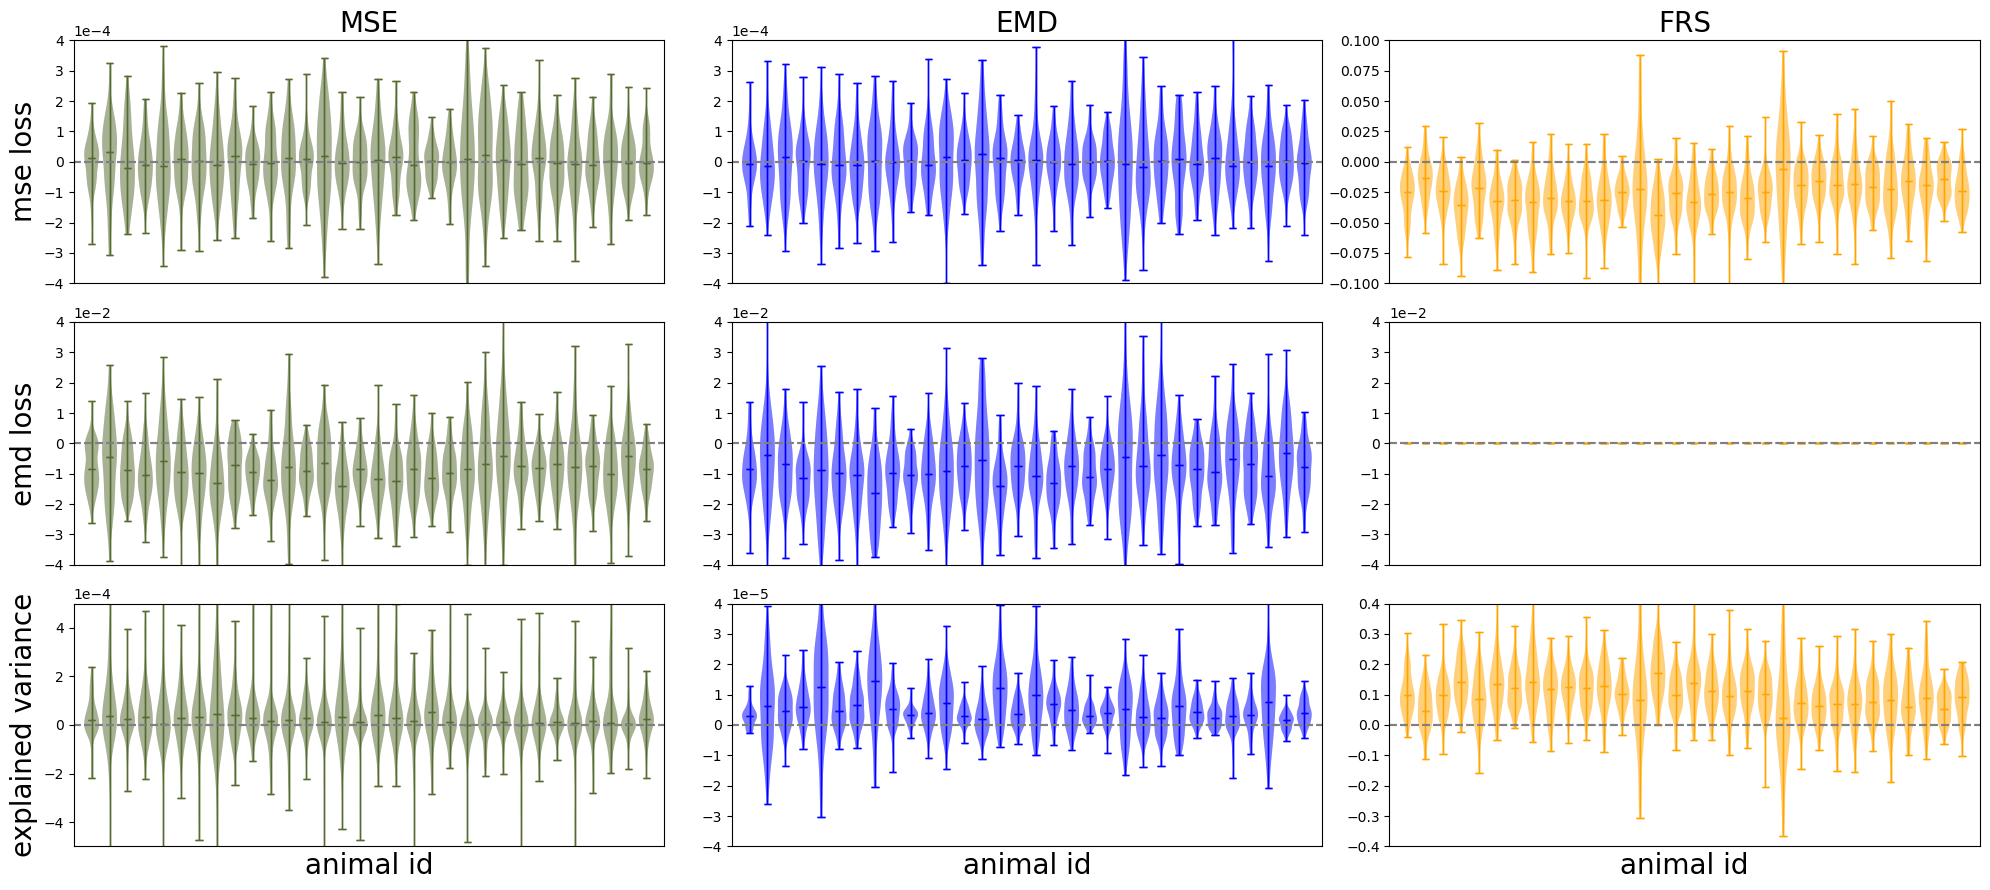

In [149]:
def make_violin(ax,results,color):
    reshaped = results.reshape(32,100,2)
    violin_parts = ax.violinplot([reshaped[m,:,0]-reshaped[m,:,1] for m in range(32)],positions=[n*.6 for n in range(32)],showmedians=True)

    # Make all the violin statistics marks red:
    for partname in ('cbars','cmins','cmaxes','cmedians', 'bodies'):
        vp = violin_parts[partname]
        if partname=='bodies':
            for k in range(len(vp)):
                vp[k].set_alpha(.3)
                vp[k].set_facecolor(color)
        else:
            vp.set_edgecolor(color)
            vp.set_linewidth(1)
    return ax

all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(20,9))

for i in range(len(all_metrics)):
    for j in range(2):

        ax[i,0] = make_violin(ax[i,0],results_mse[:,i],'darkolivegreen')
        ax[i,0].set_xticks([])
        ax[i,0].set_ylabel(all_metrics[i],fontsize=20)
        ax[i,0].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
        ax[i,0].hlines(0,-1,32*.6,linestyles='dashed',colors='grey')
        ax[i,0].set_xlim([-.6,32*.6])

        ax[i,1] = make_violin(ax[i,1],results_emd[:,i],'blue')
        ax[i,1].set_xticks([])
        #ax[i,1].set_ylim([min(np.quantile(results_emd[:,i],.1,axis=0)), max(np.quantile(results_emd[:,i],.9,axis=0))])
        ax[i,1].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
        ax[i,1].hlines(0,-1,32*.6,linestyles='dashed',colors='grey')
        ax[i,1].set_xlim([-.6,32*.6])
        
        ax[i,2] = make_violin(ax[i,2],results_frs[:,i],'orange')
        ax[i,2].set_xticks([])
        ax[i,2].ticklabel_format(axis='both', style='sci', scilimits=(-2,1))
        ax[i,2].hlines(0,-1,32*.6,linestyles='dashed',colors='grey')
        ax[i,2].set_xlim([-.6,32*.6])

ax[0,0].set_title('MSE',fontsize=20)
ax[0,0].set_ylim([-4e-4,4e-4])
ax[0,1].set_title('EMD',fontsize=20)
ax[0,1].set_ylim([-4e-4,4e-4])
ax[0,2].set_title('FRS',fontsize=20)
ax[0,2].set_ylim([-.1,.1])
ax[1,1].set_ylim([-4e-2,4e-2])
ax[1,0].set_ylim([-4e-2,4e-2])
ax[1,2].set_ylim([-4e-2,4e-2])
ax[2,1].set_ylim([-4e-5,4e-5])
ax[2,0].set_ylim([-5e-4,5e-4])
ax[2,2].set_ylim([-.4,.4])
for c in range(3):
    ax[2,c].set_xlabel('animal id',fontsize=20)
#ax[i,0].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)
#ax[i,1].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)
#ax[i,2].set_xticks([1,1.5], ['same\nimage', 'different\nimage'], rotation=45,fontsize=12)

fig.tight_layout()

In [150]:
fig.savefig('../figures/results_allen_per_animal.pdf', bbox_inches = 'tight')

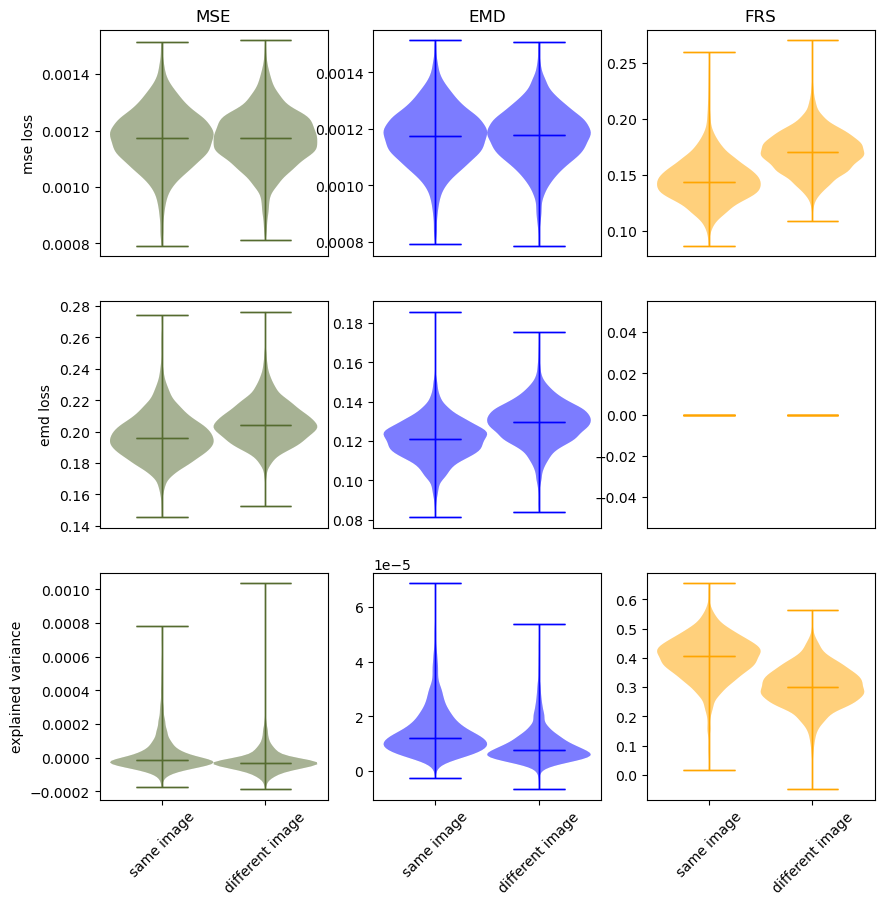

In [179]:
def make_violin(ax,results,color):

    violin_parts = ax.violinplot(results,positions=[1,1.5],showmedians=True)

    # Make all the violin statistics marks red:
    for partname in ('cbars','cmins','cmaxes','cmedians', 'bodies'):
        vp = violin_parts[partname]
        if partname=='bodies':
            for k in range(len(vp)):
                vp[k].set_alpha(.3)
                vp[k].set_facecolor(color)
        else:
            vp.set_edgecolor(color)
            vp.set_linewidth(1)
    return ax

all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):
    for j in range(2):

        ax[i,0] = make_violin(ax[i,0],results_mse[:,i],'darkolivegreen')
        #ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[i,0].set_xticks([])
        ax[i,0].set_ylabel(all_metrics[i])

        ax[i,1] = make_violin(ax[i,1],results_emd[:,i],'blue')
        ax[i,1].set_xticks([])
        
        ax[i,2] = make_violin(ax[i,2],results_frs[:,i],'orange')
        ax[i,2].set_xticks([])


ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')
ax[i,0].set_xticks([1,1.5], ['same image', 'different image'], rotation=45)
ax[i,1].set_xticks([1,1.5], ['same image', 'different image'], rotation=45)
ax[i,2].set_xticks([1,1.5], ['same image', 'different image'], rotation=45)

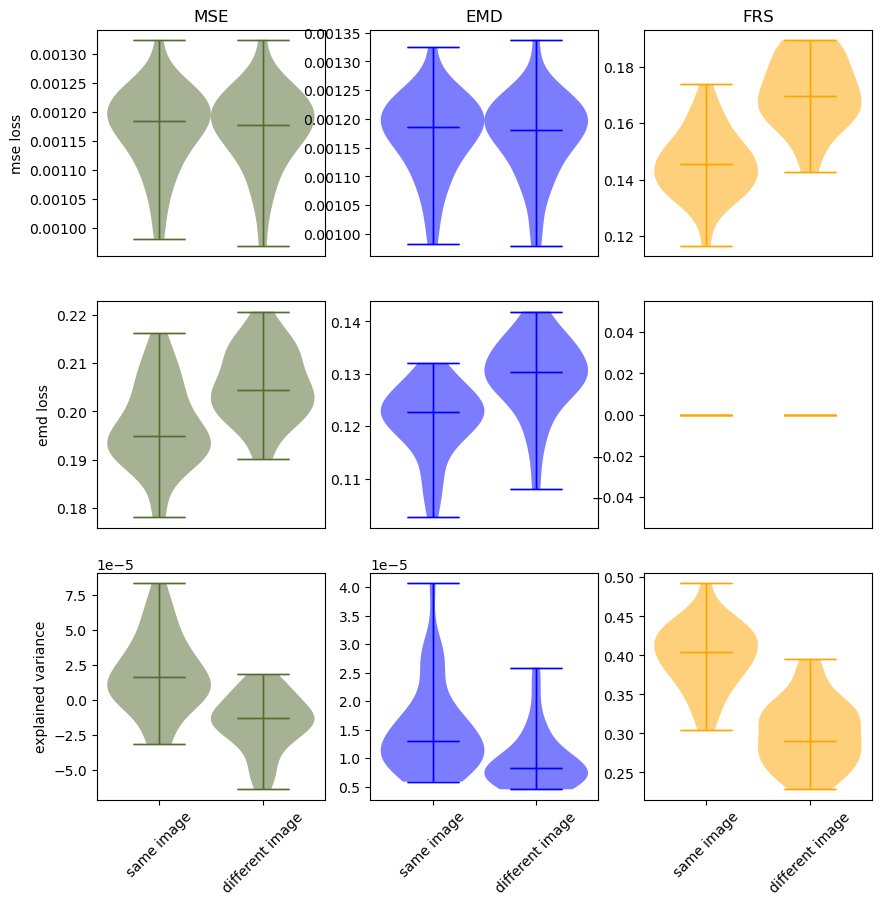

In [88]:
all_metrics = ['mse loss', 'emd loss', 'explained variance']
fig, ax = plt.subplots(len(all_metrics),3,figsize=(10,10))
for i in range(len(all_metrics)):
    for j in range(2):

        ax[i,0] = make_violin(ax[i,0],results_mse[:,i].reshape(32,100,2).mean(dim=1),'darkolivegreen')
        #ax[i,0].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[i,0].set_xticks([])
        ax[i,0].set_ylabel(all_metrics[i])

        ax[i,1] = make_violin(ax[i,1],results_emd[:,i].reshape(32,100,2).mean(dim=1),'blue')
        ax[i,1].set_xticks([])
        
        ax[i,2] = make_violin(ax[i,2],results_frs[:,i].reshape(32,100,2).mean(dim=1),'orange')
        ax[i,2].set_xticks([])


ax[0,0].set_title('MSE')
ax[0,1].set_title('EMD')
ax[0,2].set_title('FRS')
ax[i,0].set_xticks([1,1.5], ['same image', 'different image'], rotation=45)
ax[i,1].set_xticks([1,1.5], ['same image', 'different image'], rotation=45)
ax[i,2].set_xticks([1,1.5], ['same image', 'different image'], rotation=45)

In [15]:
training_parameters_emd_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : Falseformulaire
}

NameError: name 'data' is not defined

In [ ]:
results_emd_nonorm, weights_emd_nornorm = reconstruction_comparison(dataset_name,data,training_parameters_emd_nonorm,metric_names,saving_path=saving_path,device=device)

In [ ]:
training_parameters_mse_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
results_mse_nonorm, weights_mse_nonorm = reconstruction_comparison(dataset_name,data,training_parameters_mse_nonorm,metric_names,saving_path=saving_path,device=device)

In [ ]:
all_metrics = ['mse loss', 'emd loss', 'explained variance', 'similarity', 'mse', 'emd', 'factors']
fig, ax = plt.subplots(2,results_emd.shape[1],figsize=(16,6))
for i in range(results_emd.shape[1]):
    for j in range(2):
        mean_mse, std_mse = results_mse_nonorm[:,i].mean(dim=0), results_mse_nonorm[:,i].std(dim=0)
        mean_emd, std_emd = results_emd_nonorm[:,i].mean(dim=0), results_emd_nonorm[:,i].std(dim=0)
        ax[0,i].bar(j,mean_mse[j],color='darkolivegreen',alpha=.3)
        ax[0,i].errorbar(j, mean_mse[j], yerr=std_mse[j], fmt='-o', color='darkolivegreen')
        ax[0,i].set_ylim([min(mean_mse)-2*max(std_mse), max(mean_mse)+2*max(std_mse)])
        ax[0,i].set_title(all_metrics[i])
        ax[0,0].set_ylabel('MSE')
        ax[0,i].set_xticks([])
        #ax[0,i].set_yscale('log', base=10)
        ax[1,i].bar(j,mean_emd[j],color='blue',alpha=.3)
        ax[1,i].errorbar(j, mean_emd[j], yerr=std_emd[j], fmt='-o', color='blue')
        ax[1,i].set_ylim([min(mean_emd)-2*max(std_emd), max(mean_emd)+2*max(std_emd)])
        ax[1,i].set_xticks([0,1], ['in distribution', 'out distribution'], rotation=45)
        ax[1,0].set_ylabel('EMD')

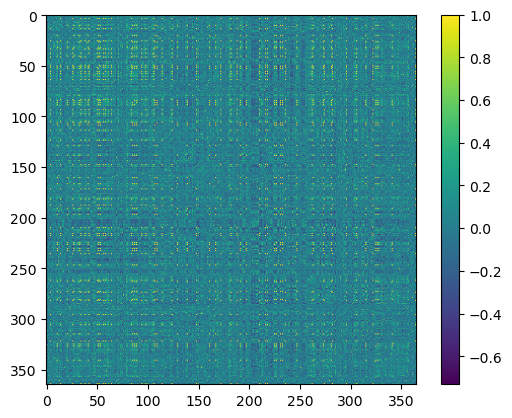

In [25]:
similarity_matrix_emd = torch.corrcoef(weights_emd.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_emd-torch.eye(similarity_matrix_emd.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_emd.div(torch.norm(weights_emd, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
training_parameters_mse = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [ ]:
weights_mse = extract_weights(data, 5, training_parameters_mse, device)

In [ ]:
similarity_matrix_mse = torch.corrcoef(weights_mse.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_mse-torch.eye(similarity_matrix_mse.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_mse.div(torch.norm(weights_mse, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
training_parameters_emd_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 1,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
weights_emd_nonorm = extract_weights(data, 5, training_parameters_emd_nonorm, device)

In [ ]:
similarity_matrix_emd_nonorm = torch.corrcoef(weights_emd_nonorm.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_emd_nonorm-torch.eye(similarity_matrix_emd_nonorm.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_emd_nonorm.div(torch.norm(weights_mse, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
training_parameters_mse_nonorm = {
    'kernel_size' : (1, data.shape[1], data.shape[2]),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [ ]:
weights_mse_nonorm = extract_weights(data, 5, training_parameters_mse_nonorm, device)

In [ ]:
similarity_matrix_nonorm = torch.corrcoef(weights_mse_nonorm.flatten(end_dim=1).squeeze(1).flatten(start_dim=1))
plt.imshow(similarity_matrix_nonorm-torch.eye(similarity_matrix_nonorm.shape[0]))
plt.colorbar()

In [ ]:
kernels = weights_mse_nonorm.div(torch.norm(weights_mse_nonorm, p=1, dim=(-1), keepdim=True)+1e-14).flatten(end_dim=1).squeeze(1)
true_matrix = kernels.unsqueeze(0).repeat(kernels.shape[0],1,1,1)
learnt_matrix = kernels.unsqueeze(1).repeat(1,kernels.shape[0],1,1)
error_matrix = torch_cdf_loss(true_matrix,learnt_matrix,'same',False).mean(axis=-1)
plt.imshow(error_matrix)
plt.colorbar()

In [ ]:
plt.imshow(similarity_matrix_mse-similarity_matrix_emd);
plt.colorbar();

In [ ]:
plt.imshow(similarity_matrix_mse-similarity_matrix_nonorm)
plt.colorbar()

1. Do the training on different images for the same animal. (no fold)
2. Check how similar are the patterns for one image to another. Can we decode images with one temporal sequence ? Or this sequence is shared for every stimuli (does not mean there is no sequence for each stimuli but that the response is dominated by this main one)
3. - If yes: check which metric helps to decode better (if EMD -> end, if MSE not normalized input then precise sequences help to decode better)
   - If not: can we add another kernel on top of this to see wether there is another sequence ? (can be infinite...)

In [ ]:
similarity_matrix_nonorm = torch.corrcoef(torch.vstack([weights_mse_nonorm.flatten(end_dim=1).squeeze(1).flatten(start_dim=1),weights_mse.flatten(end_dim=1).squeeze(1).flatten(start_dim=1)]))
plt.imshow(similarity_matrix_nonorm-torch.eye(similarity_matrix_nonorm.shape[0]))
plt.colorbar()

In [ ]:
similarity_matrix_nonorm = torch.corrcoef(torch.vstack([weights_emd.flatten(end_dim=1).squeeze(1).flatten(start_dim=1),weights_mse.flatten(end_dim=1).squeeze(1).flatten(start_dim=1)]))
plt.imshow(similarity_matrix_nonorm)
plt.colorbar()